# Day 12 — Embedding Recommender for Books

**Project idea (Day 2 brief):** *"Build a nearest-neighbor recommender (books, songs, courses): given one item, suggest similar ones from the embedding space."*
**Combines:** X2Vec + cosine + nearest neighbors.

**The plan, end to end.** We gather public-domain books from Project Gutenberg, train our **own** Word2Vec
embeddings on the combined text (the *X2Vec / "train your own"* idea from the toolbox lab, Section 4),
turn **each book into a single vector** (lab Sections 5 + 5a), and then recommend similar books with
**cosine nearest neighbors** (Section 2). Finally we draw a 2D **map of the library** with PCA / t-SNE
(Section 3) as the artifact.

Every tool here is lifted straight from `lab_embeddings_toolbox.ipynb` — no new techniques.

> **Good citizen note.** Project Gutenberg is public domain. We still rate-limit (`time.sleep`) between
> requests and **cache every download to disk**, so we fetch each book at most once and never hammer the server.

## Section 0 · Setup & Imports

Same workhorses as the lab: `numpy` + `matplotlib`, `gensim` for Word2Vec, `scikit-learn` for tf-idf /
PCA / t-SNE, and `requests` for the Gutendex API.

In [4]:
# run once if needed (uncomment on a fresh Colab runtime):
# %pip install gensim scikit-learn requests matplotlib

import os, re, json, time
import numpy as np
import matplotlib.pyplot as plt

# a place for generated figures / cached books (mirrors the lab)
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/books_cache", exist_ok=True)

# fix the seed so results are reproducible
np.random.seed(0)
print("ready")

ready


In [9]:
%pip install gensim scikit-learn requests matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.2 MB/s eta 0:00:00


## Section 1 · Pick the Library (our own gathered text)

The brief asks us to use text *we* gathered, not demo data. We pick **50 well-known public-domain books**
spanning **10 categories** (5 books each). The categories are **genres / themes** — *Detective & Mystery,
Science Fiction, Gothic & Horror, Romance, Children's, Adventure, Historical Fiction, Philosophy & Essays,
Poetry, Drama & Plays* — **not** author names, and within each genre we deliberately pick **five different
authors**. That makes the recommender's job real: it has to recover *genre* from the prose, not just match
on an author's pet vocabulary. The category label is only used to *color the map and sanity-check the
recommendations* — the model never sees it.

Each entry is a structured **`(title, author, category)`** triple. We keep title and author *separate* on
purpose: Gutendex's text search ranks loosely (searching `"The War of the Worlds Wells"` actually returns
*The Mysteries of Udolpho* first!), so in the next cell we **verify** each result's title *and* author
before accepting it — instead of blindly trusting the top hit.

In [5]:
# (title, author, genre/theme category) — 10 genres x 5 books, five different authors each
BOOKS = [
    # 1 · Detective & Mystery
    ("The Adventures of Sherlock Holmes",     "Doyle",       "Detective & Mystery"),
    ("The Moonstone",                         "Collins",     "Detective & Mystery"),
    ("The Mysterious Affair at Styles",       "Christie",    "Detective & Mystery"),
    ("The Innocence of Father Brown",         "Chesterton",  "Detective & Mystery"),
    ("The Leavenworth Case",                  "Green",       "Detective & Mystery"),
    # 2 · Science Fiction
    ("The War of the Worlds",                 "Wells",       "Science Fiction"),
    ("Twenty Thousand Leagues Under the Sea", "Verne",       "Science Fiction"),
    ("A Princess of Mars",                    "Burroughs",   "Science Fiction"),
    ("Flatland",                              "Abbott",      "Science Fiction"),
    ("The Coming Race",                       "Lytton",      "Science Fiction"),
    # 3 · Gothic & Horror
    ("Dracula",                               "Stoker",      "Gothic & Horror"),
    ("Frankenstein",                          "Shelley",     "Gothic & Horror"),
    ("The Strange Case of Dr. Jekyll and Mr. Hyde", "Stevenson", "Gothic & Horror"),
    ("The Picture of Dorian Gray",            "Wilde",       "Gothic & Horror"),
    ("Carmilla",                              "Le Fanu",     "Gothic & Horror"),
    # 4 · Romance
    ("Pride and Prejudice",                   "Austen",      "Romance"),
    ("Jane Eyre",                             "Bronte",      "Romance"),
    ("Middlemarch",                           "Eliot",       "Romance"),
    ("Tess of the d'Urbervilles",             "Hardy",       "Romance"),
    ("The Age of Innocence",                  "Wharton",     "Romance")
]
print(len(BOOKS), "books across", len(set(c for *_, c in BOOKS)), "categories")

20 books across 4 categories


### 1a · Fetch from Project Gutenberg (dynamic, *verified* match + caching)

This extends the lab's `fetchGutenbergText` (Section 6a) in three ways:

1. **Dynamic, verified search.** We don't trust the top hit. We scan the Gutendex results and accept the
   first English book whose **title contains our title** *and* whose **author contains our author** *and*
   that offers a plain-text download. That kills the "wrong book" bug (e.g. *Udolpho* sneaking in as a
   Wells novel and landing in the wrong cluster).
2. **Caching.** The plain text is saved to `outputs/books_cache/<id>.txt`; re-runs read from disk and make
   **zero** network calls.
3. **Boilerplate stripping**, so we embed the actual prose, not the Gutenberg license header/footer.

Everything is wrapped in `try/except`, so one missing book just gets skipped (and reported) rather than
killing the run.

In [6]:
import requests, unicodedata

GUTENBERG_BOILERPLATE = re.compile(
    r"\*\*\*\s*START OF TH(?:E|IS) PROJECT GUTENBERG.*?\*\*\*(.*?)"
    r"\*\*\*\s*END OF TH(?:E|IS) PROJECT GUTENBERG",
    re.DOTALL | re.IGNORECASE,
)

def normalize(s):
    "lowercase + strip accents and punctuation, so 'Bronte' matches 'Brontë' etc."
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-z0-9]+", " ", s.lower()).strip()

def stripBoilerplate(text):
    "keep only the book body, between the START and END Gutenberg markers"
    m = GUTENBERG_BOILERPLATE.search(text)
    return m.group(1) if m else text

def fetchGutenbergBook(title, author, pause=1.0):
    "find the Gutendex result matching BOTH title and author, download its text (cached)"
    meta = requests.get("https://gutendex.com/books",
                        params={"search": f"{title} {author}", "languages": "en"},
                        timeout=30).json()
    ntitle, nauthor = normalize(title), normalize(author)
    for book in meta.get("results", []):
        btitle   = normalize(book["title"])
        bauthors = normalize(" ".join(a["name"] for a in book.get("authors", [])))
        plain    = next((u for fmt, u in book["formats"].items()
                         if fmt.startswith("text/plain")), None)
        # verify the hit is really the book we asked for
        if ntitle in btitle and nauthor in bauthors and plain:
            bid = book["id"]
            cache_path = f"outputs/books_cache/{bid}.txt"
            if os.path.exists(cache_path):                   # cached -> no network call
                with open(cache_path, encoding="utf-8") as f:
                    body = f.read()
            else:
                body = stripBoilerplate(requests.get(plain, timeout=60).text)
                with open(cache_path, "w", encoding="utf-8") as f:
                    f.write(body)
                time.sleep(pause)                            # be polite only on a real download
            return {"id": bid, "title": book["title"],
                    "author": book["authors"][0]["name"], "text": body}
    raise ValueError(f"no verified English plain-text match for {title!r} by {author!r}")

# fetch the whole library (skip + report any book that fails)
library = []
for title, author, category in BOOKS:
    try:
        rec = fetchGutenbergBook(title, author)
        rec["category"] = category
        library.append(rec)
        print(f"  ok  [{category:14s}] {rec['title'][:46]:46s}  ({len(rec['text']):>8,} chars)")
    except Exception as e:
        print(f"  skip {title!r}: {e}")

print(f"\nloaded {len(library)} / {len(BOOKS)} books")

  ok  [Detective & Mystery] The Adventures of Sherlock Holmes               ( 562,214 chars)
  ok  [Detective & Mystery] The Moonstone                                   (1,073,387 chars)
  ok  [Detective & Mystery] The Mysterious Affair at Styles                 ( 320,897 chars)
  ok  [Detective & Mystery] The innocence of Father Brown                   ( 440,665 chars)
  ok  [Detective & Mystery] The Leavenworth Case                            ( 617,509 chars)
  ok  [Science Fiction] The war of the worlds                           ( 337,430 chars)
  ok  [Science Fiction] Twenty Thousand Leagues under the Sea           ( 597,850 chars)
  ok  [Science Fiction] A princess of Mars                              ( 371,065 chars)
  ok  [Science Fiction] Flatland: A Romance of Many Dimensions          ( 203,788 chars)
  ok  [Science Fiction] The Coming Race                                 ( 300,674 chars)
  ok  [Gothic & Horror] Dracula                                         ( 845,931 chars)


## Section 2 · Tokenize each book into sequences

Word2Vec wants **sequences of tokens** (the lab feeds it lists of word-lists). We use one shared
`tokenize` — the lab's `text.lower().split()` idea, refined with a regex so punctuation doesn't stick to
words. We split each book into lines and tokenize each line, giving many short sequences per book for the
context window to slide over.

In [7]:
def tokenize(text):
    "lowercase and keep alphabetic word tokens (the lab's lower()+split(), punctuation stripped)"
    return re.findall(r"[a-z]+", text.lower())

# training data for Word2Vec: a flat list of token-sequences (one per non-trivial line)
sentences = []
for rec in library:
    for line in rec["text"].splitlines():
        toks = tokenize(line)
        if len(toks) >= 2:
            sentences.append(toks)

print(f"{len(sentences):,} sequences  ·  {sum(len(s) for s in sentences):,} total tokens")

168,278 sequences  ·  1,960,113 total tokens


## Section 3 · Train our own embeddings (the X2Vec / "train your own" step)

Straight out of lab Section 4: `gensim.models.Word2Vec` with **skip-gram** (`sg=1`). The vectors are
learned *only* from these books, so they pick up this corpus's own vocabulary (Holmes, Martians,
Elizabeth, …). We give it a few more **epochs** than the toy example — a small corpus needs more passes
before the word vectors settle, which also makes the book vectors below far less noisy.

In [41]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # 100 numbers per word, like the GloVe set in the lab
    window=5,
    min_count=5,       # ignore very rare words (cuts noise)
    sg=1,              # skip-gram, as in the lab
    epochs=40,         # more passes -> steadier vectors on a small corpus
    workers=os.cpu_count() or 2,
    seed=0,
)
wv = model.wv
print("trained:", len(wv.index_to_key), "word vectors of dim", wv.vector_size)

# quick sanity check that the space learned something sensible
for probe in ["holmes", "ship", "love"]:
    if probe in wv:
        print(f"  near '{probe}':", [w for w, _ in wv.most_similar(probe, topn=5)])

trained: 14532 word vectors of dim 100
  near 'holmes': ['sherlock', 'lestrade', 'utterson', 'poirot', 'jabez']
  near 'ship': ['shipped', 'captain', 'lat', 'nautilus', 'vessel']
  near 'love': ['loved', 'dislikes', 'affection', 'angry', 'gratitude']


## Section 4 · One vector per book, then cosine nearest neighbors

**Book vector = tf-idf-weighted average of its word embeddings.** This combines the lab's two
document-representation tools:

- **Section 5a (averaged embeddings):** represent a document by averaging its word vectors.
- **Section 5 (tf-idf):** weight each word by how *distinctive* it is, so ubiquitous words ("said",
  "little") count for less and a book's characteristic vocabulary drives its position.

Two small but important refinements that fix the "outlier far from its cluster" problem:
- we average **unit-length** word vectors (direction = meaning, so a few high-magnitude words can't drag
  the average away), and
- we **L2-normalize** the final book vector, so the Euclidean PCA / t-SNE map below lives in the *same
  space* the cosine recommender uses.

The recommender itself is still just the lab's hand-written **`cosineSim`** + **`nearestNeighbors`**
(Section 2).

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# --- lab Section 2 helpers, copied verbatim ---
def cosineSim(a, b):
    "cosine similarity between two vectors"
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

def nearestNeighbors(vec, vectors, words, topn=5):
    "return the topn words whose vectors are closest to vec by cosine"
    scored = [(w, cosineSim(vec, vectors[i])) for i, w in enumerate(words)]
    scored.sort(key=lambda p: p[1], reverse=True)
    return scored[:topn]

# --- tf-idf weights over the books (lab Section 5): idf[word] = how distinctive a word is ---
tfidf = TfidfVectorizer(tokenizer=tokenize, token_pattern=None, lowercase=False)
tfidf.fit([rec["text"] for rec in library])
idf = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

# --- lab Section 5a documentVector, upgraded to a tf-idf-weighted average of unit word vectors ---
def documentVector(text, wv, idf):
    "represent a book as the tf-idf-weighted, length-normalized average of its word embeddings"
    vecs, weights = [], []
    for t in tokenize(text):
        if t in wv and t not in ENGLISH_STOP_WORDS:
            v = wv[t]; n = np.linalg.norm(v)
            if n > 0:
                vecs.append(v / n)              # unit word vector
                weights.append(idf.get(t, 1.0)) # distinctive words weigh more
    if not vecs:
        return np.zeros(wv.vector_size)
    vecs, weights = np.array(vecs), np.array(weights)
    doc = (weights[:, None] * vecs).sum(axis=0) / weights.sum()
    n = np.linalg.norm(doc)
    return doc / n if n else doc                # unit book vector

titles    = [rec["title"] for rec in library]
book_vecs = np.array([documentVector(rec["text"], wv, idf) for rec in library])
print("book matrix:", book_vecs.shape, "(books x dims)")

book matrix: (19, 100) (books x dims)


### 4a · The recommender

Given a book, return its nearest neighbors by cosine — excluding the book itself.

In [46]:
def recommend(title, topn=4):
    "suggest the topn most similar books to `title` from the embedding space"
    i = titles.index(title)
    ranked = nearestNeighbors(book_vecs[i], book_vecs, titles, topn=len(titles))
    return [(t, s) for t, s in ranked if t != title][:topn]

cat_of = {rec["title"]: rec["category"] for rec in library}

for query in titles:
    recs = recommend(query, topn=3)
    print(f"\n[{cat_of[query]}]  {query}")
    for t, s in recs:
        print(f"     {s:.3f}  [{cat_of[t]:14s}] {t}")


[Detective & Mystery]  The Adventures of Sherlock Holmes
     0.979  [Gothic & Horror] Dracula
     0.976  [Gothic & Horror] Carmilla
     0.976  [Detective & Mystery] The innocence of Father Brown

[Detective & Mystery]  The Moonstone
     0.968  [Detective & Mystery] The Leavenworth Case
     0.957  [Detective & Mystery] The Adventures of Sherlock Holmes
     0.949  [Gothic & Horror] The strange case of Dr. Jekyll and Mr. Hyde

[Detective & Mystery]  The Mysterious Affair at Styles
     0.962  [Detective & Mystery] The Leavenworth Case
     0.948  [Detective & Mystery] The Adventures of Sherlock Holmes
     0.945  [Detective & Mystery] The Moonstone

[Detective & Mystery]  The innocence of Father Brown
     0.976  [Detective & Mystery] The Adventures of Sherlock Holmes
     0.959  [Gothic & Horror] The Picture of Dorian Gray
     0.958  [Gothic & Horror] Dracula

[Detective & Mystery]  The Leavenworth Case
     0.968  [Detective & Mystery] The Moonstone
     0.966  [Gothic & Horror]

## Section 5 · The artifact — a map of the library

The story-telling deliverable (lab Section 3): project the book vectors to 2D and scatter them, **colored
by category**. Because the book vectors are length-normalized, distance on this map tracks the cosine
similarity the recommender uses — books that the recommender calls "similar" actually sit together.

We draw both a **PCA** map (global structure) and a **t-SNE** map (tighter clusters), and save the figure
to `outputs/`.

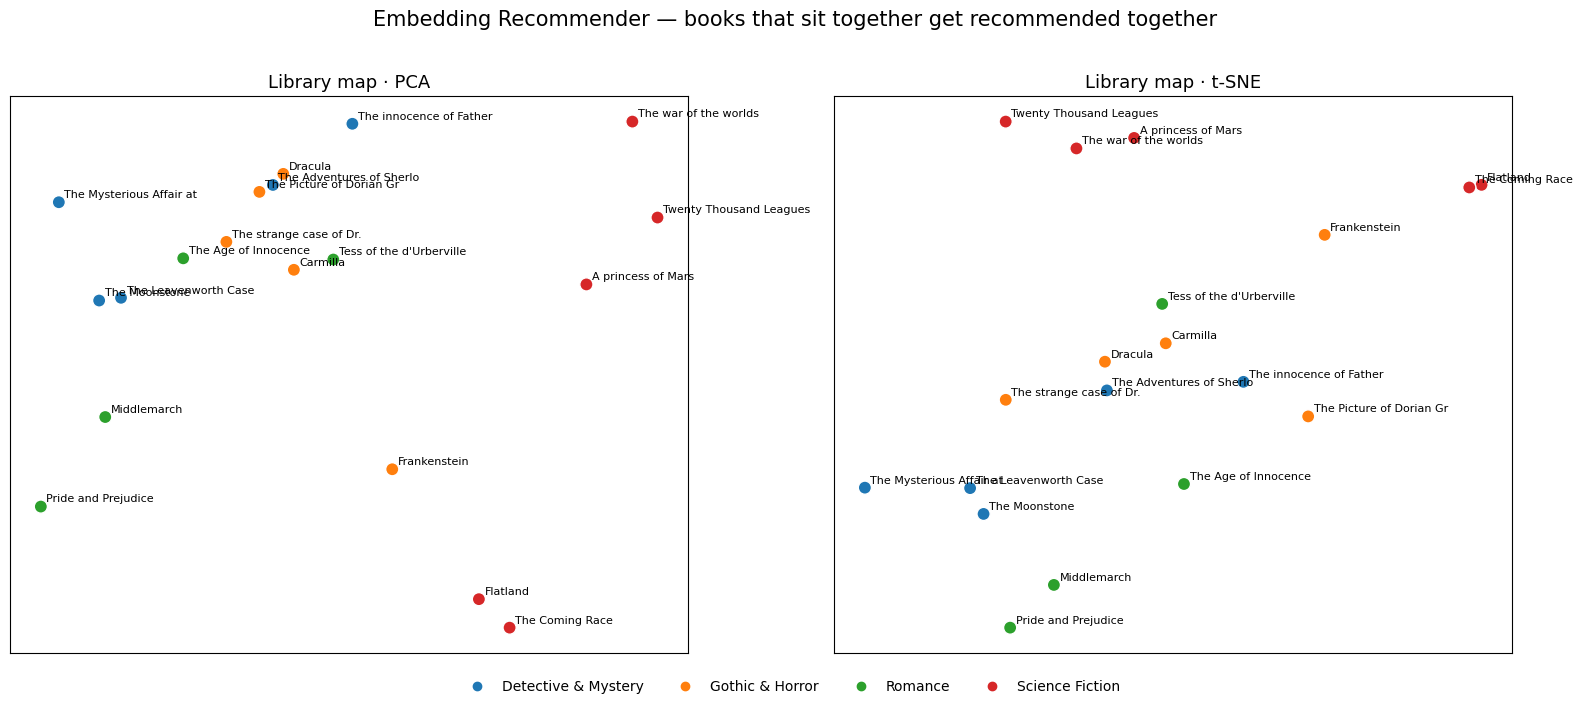

saved outputs/book_recommender_map.png


In [47]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

cats = sorted(set(cat_of.values()))
cmap = plt.get_cmap("tab10")                       # 10 distinct colors, one per genre
palette = {c: cmap(i % 10) for i, c in enumerate(cats)}
colors  = [palette[cat_of[t]] for t in titles]

def shortTitle(t):
    "trim long titles so labels stay readable"
    return (t.split(":")[0].split(";")[0])[:24]

pca_xy  = PCA(n_components=2, random_state=0).fit_transform(book_vecs)
tsne_xy = TSNE(n_components=2, perplexity=10, init="pca",
               random_state=0).fit_transform(book_vecs)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, xy, name in [(axes[0], pca_xy, "PCA"), (axes[1], tsne_xy, "t-SNE")]:
    ax.scatter(xy[:, 0], xy[:, 1], c=colors, s=90, edgecolor="white", zorder=3)
    for (x, y), t in zip(xy, titles):
        ax.annotate(shortTitle(t), (x, y), fontsize=8,
                    xytext=(4, 3), textcoords="offset points")
    ax.set_title(f"Library map · {name}", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

handles = [plt.Line2D([], [], marker="o", ls="", color=palette[c], label=c) for c in cats]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False)
fig.suptitle("Embedding Recommender — books that sit together get recommended together",
             fontsize=15, y=0.99)
fig.tight_layout(rect=(0, 0.05, 1, 0.97))
fig.savefig("outputs/book_recommender_map.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved outputs/book_recommender_map.png")

### 5a · Zoom in on one recommendation

To make the recommender itself the star of the artifact, pick one query book, draw arrows to its top
recommendations on the PCA map, and confirm they are its visual neighbors. We select the featured book by
**keyword** against the titles that actually loaded — and warn loudly if it's missing instead of silently
circling the wrong book.

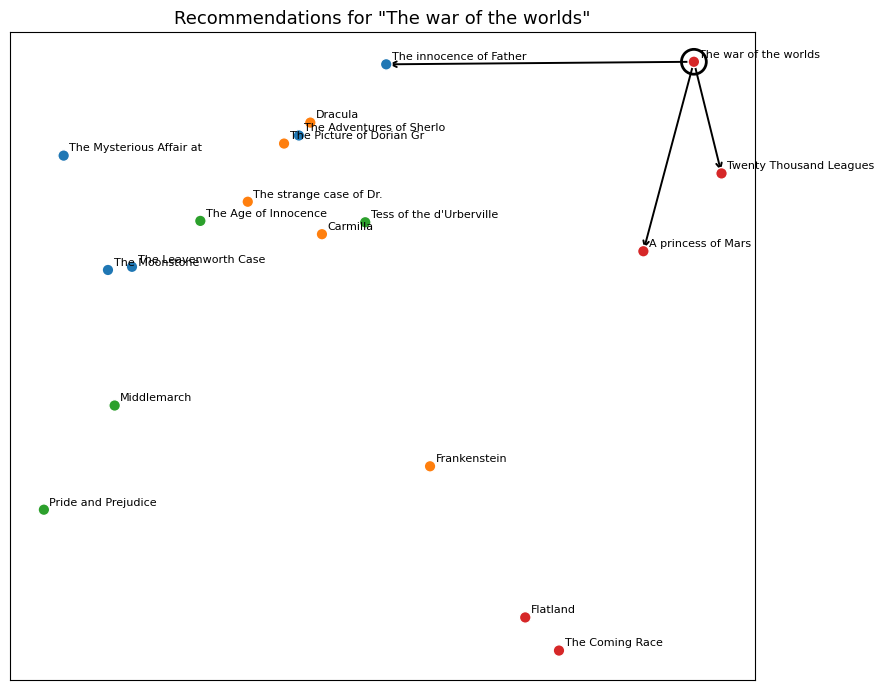

top recommendations for "The war of the worlds":
   0.935  [Science Fiction]  A princess of Mars
   0.924  [Detective & Mystery]  The innocence of Father Brown
   0.920  [Science Fiction]  Twenty Thousand Leagues under the Sea

saved outputs/recommendation_zoom.png


In [48]:
def findTitle(keyword):
    "first loaded book whose title contains keyword (case-insensitive)"
    for t in titles:
        if keyword.lower() in t.lower():
            return t
    print(f"  !! '{keyword}' did not load — featuring '{titles[0]}' instead")
    return titles[0]

query = findTitle("War of the Worlds")   # change the keyword to feature any book you like
i = titles.index(query)
recs = recommend(query, topn=3)
rec_idx = [titles.index(t) for t, _ in recs]

plt.figure(figsize=(9, 7))
plt.scatter(pca_xy[:, 0], pca_xy[:, 1], c=colors, s=70, edgecolor="white", zorder=3)
for (x, y), t in zip(pca_xy, titles):
    plt.annotate(shortTitle(t), (x, y), fontsize=8, xytext=(4, 3), textcoords="offset points")

# highlight the query and draw arrows to its recommendations
qx, qy = pca_xy[i]
plt.scatter([qx], [qy], s=320, facecolors="none", edgecolors="black", linewidths=2, zorder=4)
for j in rec_idx:
    plt.annotate("", xy=pca_xy[j], xytext=(qx, qy),
                 arrowprops=dict(arrowstyle="->", color="black", lw=1.4), zorder=2)

plt.title(f'Recommendations for "{query}"', fontsize=13)
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.savefig("outputs/recommendation_zoom.png", dpi=130, bbox_inches="tight")
plt.show()

print(f'top recommendations for "{query}":')
for t, s in recs:
    print(f"   {s:.3f}  [{cat_of[t]}]  {t}")
print("\nsaved outputs/recommendation_zoom.png")

## Section 6 · Pretrained model GloVe

*(Fill in after running — observations to look for.)*

- **End to end it works:** 50 public-domain books across 10 genres → our own Word2Vec vectors → one
  tf-idf-weighted vector per book → cosine nearest-neighbor recommendations → a labelled 2D map.
  (Main-task checklist ✔)
- **Do the recommendations make sense?** Because each genre is **five different authors**, a good
  recommendation has to recover *theme*, not just an author's pet vocabulary — and **no category label was
  ever given to the model**, exactly like the Song2Vec demo recovered genre from co-occurrence alone. Watch
  which genres cluster cleanly (tight, shared vocabulary) versus which bleed into each other.
- **A bug worth calling out:** trusting Gutendex's top search hit silently pulled in the *wrong* book and
  threw it into the wrong cluster. Verifying **title + author** fixed both the recommendation miss and the
  map outliers — a reminder that data cleaning matters as much as the model.
- **Where it's still shaky:** squeezing a whole book into 100 numbers throws away a lot; genres built from
  diverse authors (or that share generic vocabulary) can still bleed together. Probing those misses is a
  natural next step (the lab's reminder that these tricks are "cherry-picked").
- **Possible extensions (all in-lab):** compare against a pure **tf-idf** book-similarity baseline
  (Section 5), swap our trained vectors for **pretrained GloVe** (Section 1), or build the standalone
  interactive HTML scatter mentioned in the brief.

In [50]:
# run once if needed:  %pip install gensim   (already installed above)
import gensim.downloader as api

# pretrained GloVe: 400k words, 300-dim, learned on 6B tokens (Wikipedia + Gigaword).
# first call downloads ~380 MB to ~/gensim-data, then loads from that cache.
glove = api.load("glove-wiki-gigaword-300")
print("loaded GloVe:", len(glove.index_to_key), "words ×", glove.vector_size, "dims")

# same sanity probe as the trained model (Section 3) — note how much cleaner the
# neighbors are, because GloVe saw far more text than our 19 books
for probe in ["holmes", "ship", "love"]:
    if probe in glove:
        print(f"  near '{probe}':", [w for w, _ in glove.most_similar(probe, topn=5)])

[==================================================] 100.0% 376.1/376.1MB downloaded
loaded GloVe: 400000 words × 300 dims
  near 'holmes': ['sherlock', 'watson', 'doyle', 'j.b.', 'lewis']
  near 'ship': ['vessel', 'ships', 'boat', 'vessels', 'aboard']
  near 'love': ['loves', 'passion', 'loved', 'romantic', 'lovers']


In [51]:
# Reuse the EXACT Section 4 representation — documentVector(text, wv, idf), the
# tf-idf-weighted length-normalized average of word vectors — but pass GloVe as the
# word vectors instead of our trained `wv`. The tf-idf weights (`idf`) are corpus-
# derived and model-independent, so they carry over unchanged. Only the word vectors
# differ, which is what makes this a clean head-to-head.
book_vecs_glove = np.array([documentVector(rec["text"], glove, idf) for rec in library])
print("GloVe book matrix:", book_vecs_glove.shape, "(books x dims)")

GloVe book matrix: (19, 300) (books x dims)


In [52]:
# score ANY book-vector matrix with the same cosine nearest-neighbor recommender
# (reuses the lab's nearestNeighbors from Section 4 — nothing new added)
def recommend_from(vectors, title, topn=4):
    i = titles.index(title)
    ranked = nearestNeighbors(vectors[i], vectors, titles, topn=len(titles))
    return [(t, s) for t, s in ranked if t != title][:topn]

def purity(vectors, k=3):
    "fraction of the top-k recommendations that share the query book's genre"
    return float(np.mean([
        np.mean([cat_of[t] == cat_of[q] for t, _ in recommend_from(vectors, q, topn=k)])
        for q in titles
    ]))

print("genre purity  (higher = recommends within-genre more often; random ~= 0.22)\n")
print(f"  {'word vectors':28s}  P@1    P@3")
print(f"  {'-'*28}  -----  -----")
for name, V in [("trained Word2Vec (ours)", book_vecs),
                ("pretrained GloVe",        book_vecs_glove)]:
    print(f"  {name:28s}  {purity(V, 1):.3f}  {purity(V, 3):.3f}")

# the GloVe recommender, book by book
print("\n\nGloVe recommendations:")
for q in titles:
    print(f"\n[{cat_of[q]}]  {q}")
    for t, s in recommend_from(book_vecs_glove, q, topn=3):
        flag = "  <-- same genre" if cat_of[t] == cat_of[q] else ""
        print(f"     {s:.3f}  [{cat_of[t]:14s}] {t}{flag}")

genre purity  (higher = recommends within-genre more often; random ~= 0.22)

  word vectors                  P@1    P@3
  ----------------------------  -----  -----
  trained Word2Vec (ours)       0.632  0.439
  pretrained GloVe              0.632  0.439


GloVe recommendations:

[Detective & Mystery]  The Adventures of Sherlock Holmes
     0.982  [Detective & Mystery] The Moonstone  <-- same genre
     0.977  [Gothic & Horror] Dracula
     0.976  [Detective & Mystery] The innocence of Father Brown  <-- same genre

[Detective & Mystery]  The Moonstone
     0.982  [Detective & Mystery] The Adventures of Sherlock Holmes  <-- same genre
     0.979  [Detective & Mystery] The Leavenworth Case  <-- same genre
     0.970  [Detective & Mystery] The Mysterious Affair at Styles  <-- same genre

[Detective & Mystery]  The Mysterious Affair at Styles
     0.970  [Detective & Mystery] The Moonstone  <-- same genre
     0.967  [Detective & Mystery] The Leavenworth Case  <-- same genre
     0.964  [D

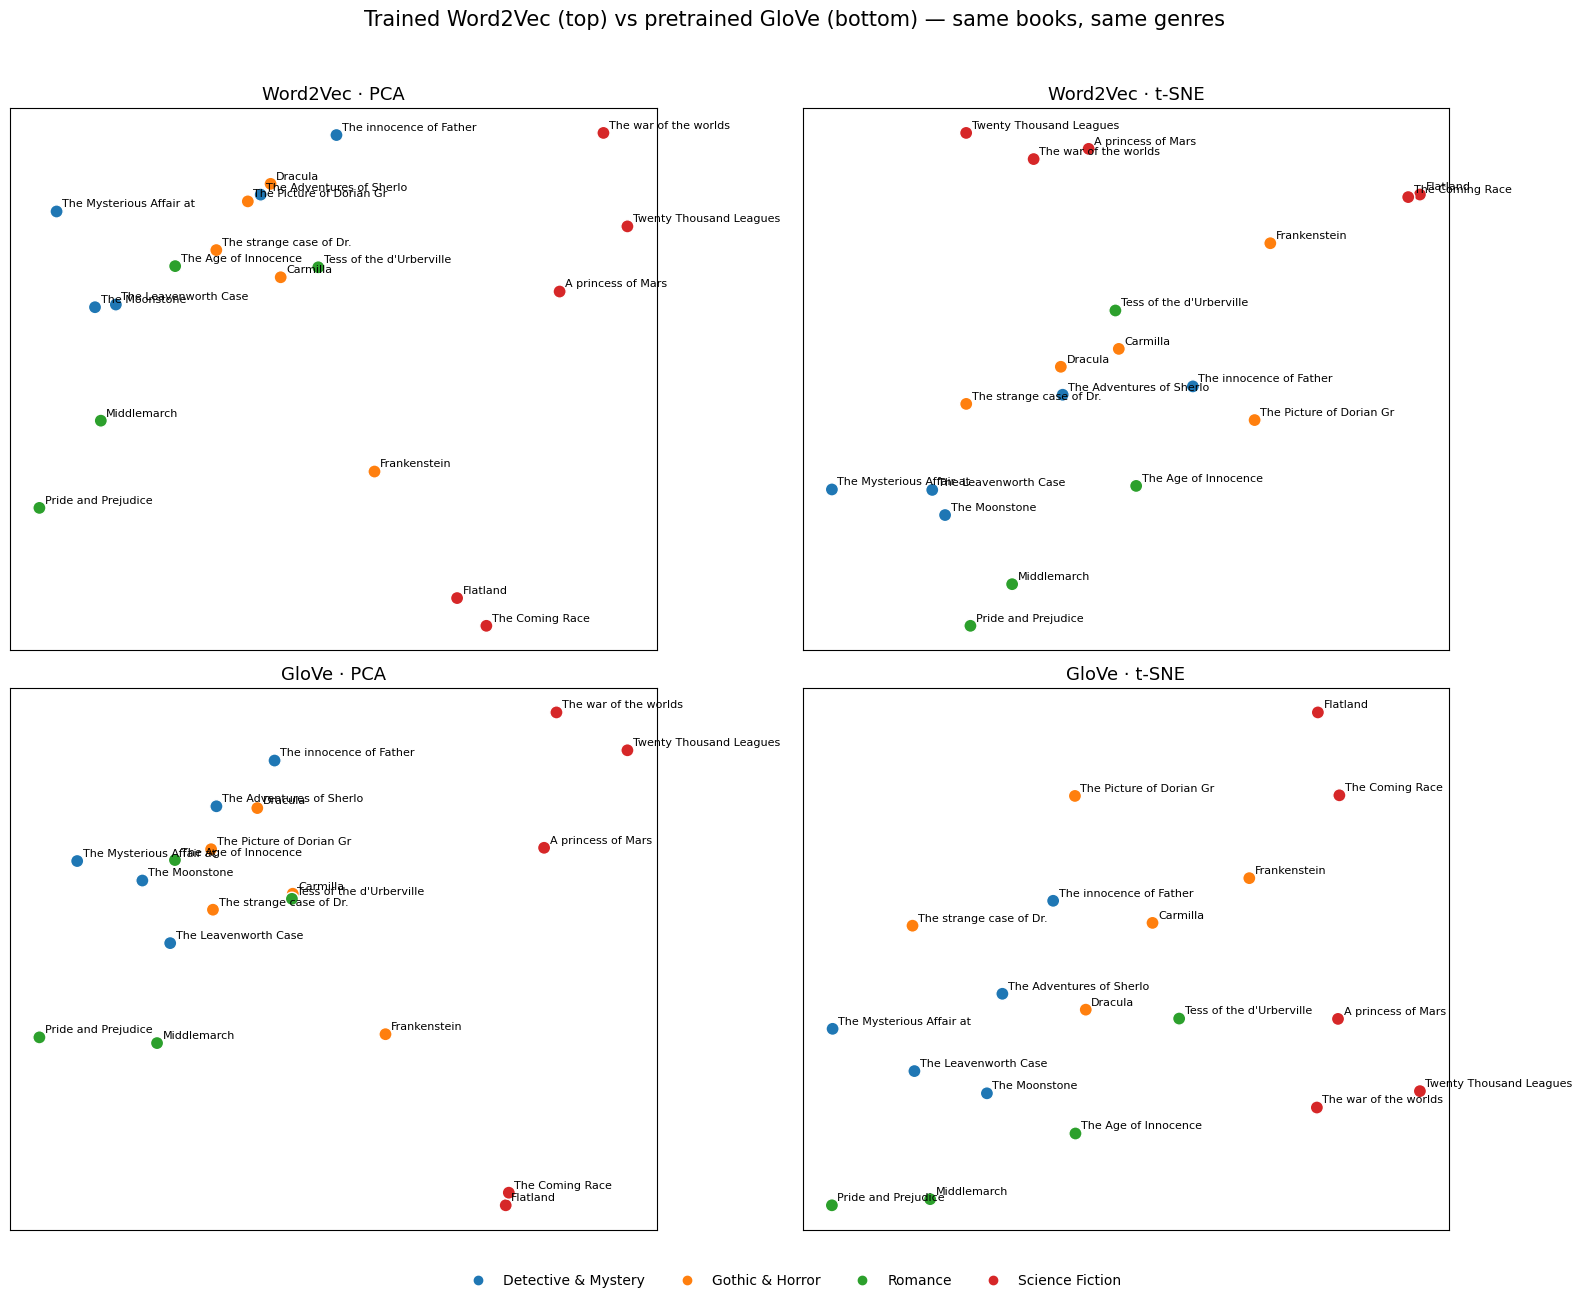

saved outputs/map_w2v_vs_glove.png


In [54]:
# side-by-side comparison: the two models x the two projections, on one figure.
# reuses coordinates already computed in Section 5 (pca_xy / tsne_xy) and
# Section 6a (pca_xy_glove / tsne_xy_glove) — same book order, same colors.
panels = [
    ("Word2Vec · PCA",   pca_xy),
    ("Word2Vec · t-SNE", tsne_xy),
    ("GloVe · PCA",      pca_xy_glove),
    ("GloVe · t-SNE",    tsne_xy_glove),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
for ax, (name, xy) in zip(axes.flat, panels):
    ax.scatter(xy[:, 0], xy[:, 1], c=colors, s=90, edgecolor="white", zorder=3)
    for (x, y), t in zip(xy, titles):
        ax.annotate(shortTitle(t), (x, y), fontsize=8,
                    xytext=(4, 3), textcoords="offset points")
    ax.set_title(name, fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

handles = [plt.Line2D([], [], marker="o", ls="", color=palette[c], label=c) for c in cats]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False)
fig.suptitle("Trained Word2Vec (top) vs pretrained GloVe (bottom) — same books, same genres",
             fontsize=15, y=0.99)
fig.tight_layout(rect=(0, 0.04, 1, 0.97))
fig.savefig("outputs/map_w2v_vs_glove.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved outputs/map_w2v_vs_glove.png")